Load data into dataframe once

In [13]:
from pathlib import Path
import pandas as pd

DATA_PATH_2021 = Path("curr_webget_2021.csv")
DATA_PATH_2023 = Path("curr_webget.csv")

df_2021 = pd.read_csv(DATA_PATH_2021, nrows=1000000)
df_2023 = pd.read_csv(DATA_PATH_2023, nrows=1000000)

In [14]:
df_2021.head()

,unit_id,dtime,target,address,fetch_time,bytes_total,bytes_sec,objects,threads,requests,...,ttfb_min,ttfb_avg,ttfb_max,lookup_total_time,lookup_min_time,lookup_avg_time,lookup_max_time,successes,failures,location_id
0,386,2021-01-01 00:41:03,http://www.bbc.com/,151.101.116.81,14439537,650162,45026,28,8,27,...,741753,3626807,5050858,34393,2915,3821,8944,1,0,77705633
1,386,2021-01-01 00:42:57,http://www.bing.com/,204.79.197.200,76978,106507,1383603,1,8,1,...,55538,55538,55538,3397,3397,3397,3397,1,0,77705633
2,386,2021-01-01 02:43:27,http://www.bbc.com/,151.101.116.81,12646000,650232,51417,28,8,27,...,667080,3676718,5184080,21747,2046,2416,3469,1,0,77705633
3,386,2021-01-01 06:39:43,http://www.apple.com/,23.33.189.9,7623768,2629152,344862,17,8,17,...,639479,4580359,5077537,2490,2490,2490,2490,1,0,77705633
4,386,2021-01-01 06:40:25,http://www.bbc.com/,151.101.116.81,15089858,650825,43129,29,8,28,...,649981,3877160,5199175,22581,2004,2509,3012,1,0,77705633


## 2. Eksploracyjna Analiza Danych (EDA) - Statystyki Opisowe i Tabele
W tej sekcji prezentowane jest wsteczne zestawienie statystyczne dla wybranych, natywnych wartości zbioru FCC: `bytes_sec` (oznaczającego realną przepustowość) oraz `ttfb_avg` (średniego czasu opóźnienia na dojściu pakietów). Poniższe tabele podsumowują zjawiska rynkowe jak średnia, mediana (50%) czy 75% kwartyl badanych serwerów z podziałem dla lat 2021 oraz 2023.

In [15]:
# Wybieramy kluczowe kolumny do tabelarycznych statystyk, nie wprowadzając zafałszowań z nowymi zmiennymi:
cols_to_describe = ['bytes_sec', 'request_total_time', 'ttfb_avg']

print("=== STATYSTYKI SUMARYCZNE: ZBIÓR 2021 ===")
display(df_2021[cols_to_describe].describe())

print("\n=== STATYSTYKI SUMARYCZNE: ZBIÓR 2023 ===")
display(df_2023[cols_to_describe].describe())

=== STATYSTYKI SUMARYCZNE: ZBIÓR 2021 ===


,bytes_sec,request_total_time,ttfb_avg
count,1.000000e+06,1.000000e+06,1.000000e+06
mean,8.449114e+05,4.335642e+07,6.276248e+05
std,8.217227e+05,1.068442e+08,1.082676e+06
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.273415e+05,4.071295e+05,1.042310e+05
50%,6.094900e+05,7.620446e+06,2.519430e+05
75%,1.214085e+06,3.205951e+07,4.019312e+05
max,4.795748e+06,1.118039e+09,2.194943e+07



=== STATYSTYKI SUMARYCZNE: ZBIÓR 2023 ===


,bytes_sec,request_total_time,ttfb_avg
count,1.000000e+06,1.000000e+06,1.000000e+06
mean,2.089797e+05,3.628561e+07,1.468320e+06
std,2.908745e+05,7.313595e+07,1.898844e+06
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.094700e+04,9.760900e+04,6.907500e+04
75%,3.517240e+05,4.533826e+07,3.377699e+06
max,2.248022e+06,5.044564e+08,1.787446e+07


### 3. Eksploracja w oparciu o wizualizacje (Histogramy 1D) - podział na Poprawne i Przerwane Łącza
Poniższe skrypty i tablice obrazują rozkład pobierania danych w badanych populacjach amerykańskiego rynku dla wczytanych parametrów. Ze względu na zjawisko błędów sieciowych i przerwanych testów (zerujących średni wynik przesyłu gigantycznymi "urwanymi" transakcjami sieci) zbiór został odseparowany dla czytelności. 
Wykres pierwszy wskazuje dystrybucję przepustowości tylko dla pomiarów powiodłych się z kodem statusu poprawnego (`successes == 1`). Wyselekcjonowanie samego 1% (percentyla `0.99`) pozwala ocenić zjawisko przesunięcia rynkowej wydajności pobierania dla zwykłych użytkowników między latami 2021 a 2023. Następnie ukazano histogram błędnych pomiarów (`successes == 0`).

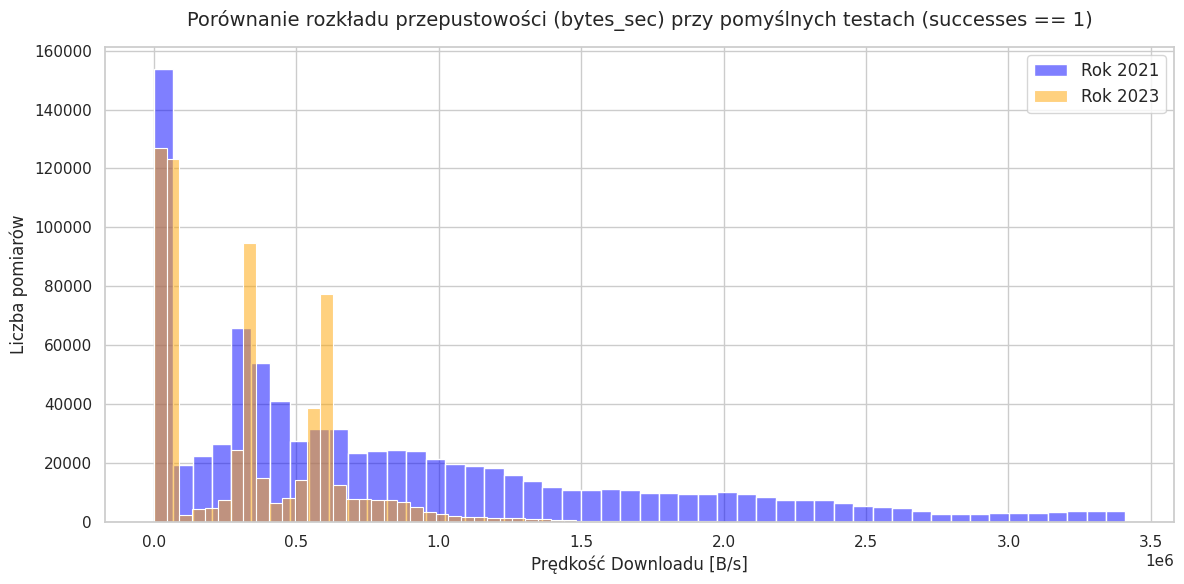

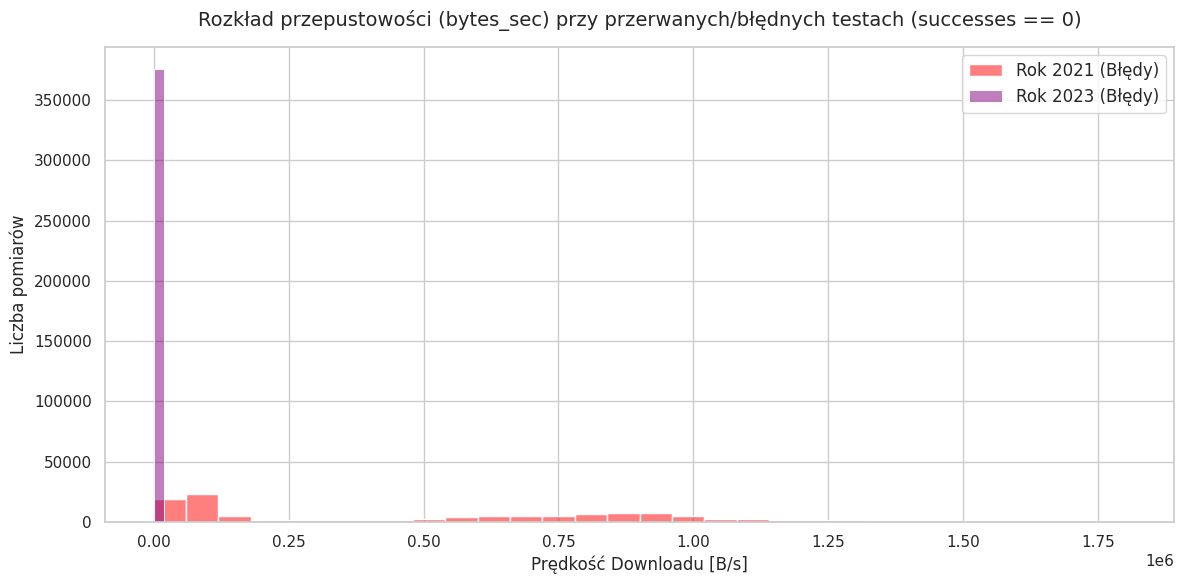

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ustawienie estetyki wykresów
sns.set_theme(style="whitegrid")

# Aby wykres był czytelny i gęstość głównych użytkowników rzucała się w oczy,
# 1. Filtrujemy tylko POPRAWNE testy (gdzie successes == 1) korzystając z natywnej kolumny
valid_21 = df_2021[df_2021['successes'] == 1]
valid_23 = df_2023[df_2023['successes'] == 1]

# Odcinamy największych skrajnych dostawców (outliery ponad 99 percentylem)
percentile_21 = valid_21['bytes_sec'].quantile(0.99) if not valid_21.empty else 0
percentile_23 = valid_23['bytes_sec'].quantile(0.99) if not valid_23.empty else 0
cap_val = max(percentile_21, percentile_23)

df_21_filtered = valid_21[valid_21['bytes_sec'] <= cap_val]
df_23_filtered = valid_23[valid_23['bytes_sec'] <= cap_val]

# --- WYKRES 1: POMYŚLNE TESTY ---
plt.figure(figsize=(12, 6))

sns.histplot(df_21_filtered['bytes_sec'], color='blue', label='Rok 2021', bins=50, alpha=0.5)
sns.histplot(df_23_filtered['bytes_sec'], color='orange', label='Rok 2023', bins=50, alpha=0.5)

plt.title('Porównanie rozkładu przepustowości (bytes_sec) przy pomyślnych testach (successes == 1)', fontsize=14, pad=15)
plt.xlabel('Prędkość Downloadu [B/s]', fontsize=12)
plt.ylabel('Liczba pomiarów', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# --- WYKRES 2: BŁĘDNE TESTY ---
# 2. Filtrujemy tylko BŁĘDNE testy (gdzie successes == 0)
invalid_21 = df_2021[df_2021['successes'] == 0]
invalid_23 = df_2023[df_2023['successes'] == 0]

invalid_cap_21 = invalid_21['bytes_sec'].quantile(0.99) if not invalid_21.empty else 0
invalid_cap_23 = invalid_23['bytes_sec'].quantile(0.99) if not invalid_23.empty else 0
invalid_cap_val = max(invalid_cap_21, invalid_cap_23)

if invalid_cap_val > 0:
    df_21_inv_filtered = invalid_21[invalid_21['bytes_sec'] <= invalid_cap_val]
    df_23_inv_filtered = invalid_23[invalid_23['bytes_sec'] <= invalid_cap_val]
else:
    df_21_inv_filtered = invalid_21
    df_23_inv_filtered = invalid_23

plt.figure(figsize=(12, 6))

sns.histplot(df_21_inv_filtered['bytes_sec'], color='red', label='Rok 2021 (Błędy)', bins=30, alpha=0.5)
sns.histplot(df_23_inv_filtered['bytes_sec'], color='purple', label='Rok 2023 (Błędy)', bins=30, alpha=0.5)

plt.title('Rozkład przepustowości (bytes_sec) przy przerwanych/błędnych testach (successes == 0)', fontsize=14, pad=15)
plt.xlabel('Prędkość Downloadu [B/s]', fontsize=12)
plt.ylabel('Liczba pomiarów', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 4. Wizualizacje Przestrzenne 2D (Wykresy Gęstości typu Hexbin)
Poniższa sekcja służy weryfikacji powiązania na wykresach przestrzeni, dla cech dwuwymiarowych: `bytes_sec` (Wydajność/Transfer jako Oś-Y) wraz z `ttfb_avg` (Obciążenia/Opóźnienia TTFB jako logarytmicznie zastosowana Oś-X z racji mikrosekundowego rozproszenia).

Z racji dużej próby sięgającej 500-tysięcy wpisów, zaniechano renderowania klasycznych Wykresów Rozrzutu (Scatter Plots), w których poszczególne pomiary i wartości punktowe najeżdżałyby na siebie efektem *overplottingu*, uchodząc nierozpoznawalnym plamom błędu. Odcienie ciepłoty kolorów pokazanych sześciokątów Hexbin pozwalają zidentyfikować faktyczne główne klastry rynkowe łączące profil prędkości w latach 2021 oraz 2023.

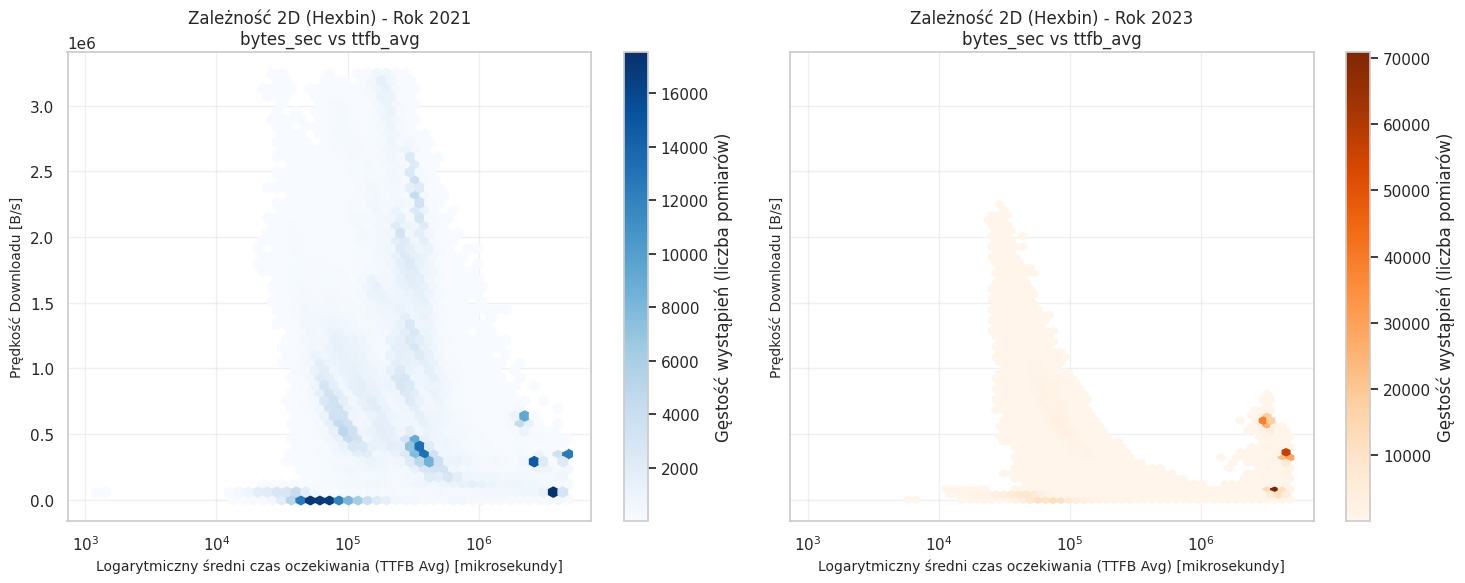

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pracujemy na bezbłędnych testach zapisanych w poprzednich krokach
valid_21 = df_2021[df_2021['successes'] == 1]
valid_23 = df_2023[df_2023['successes'] == 1]

# Dla czytelności odcinamy absolutne skrajności z "ttfb_avg" oraz z "bytes_sec"
x_col = 'ttfb_avg'
y_col = 'bytes_sec'

cap_x = max(valid_21[x_col].quantile(0.98), valid_23[x_col].quantile(0.98))
cap_y = max(valid_21[y_col].quantile(0.98), valid_23[y_col].quantile(0.98))

# Filtracja, w której zachowujemy wartości mniejsze od progu
hist_df_21 = valid_21[(valid_21[x_col] <= cap_x) & (valid_21[y_col] <= cap_y)]
hist_df_23 = valid_23[(valid_23[x_col] <= cap_x) & (valid_23[y_col] <= cap_y)]

# Wygenerowanie siatki z dwoma histogramami Hexbin obok siebie
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=True)

# Rok 2021
hb1 = axes[0].hexbin(
    hist_df_21[x_col], hist_df_21[y_col], 
    gridsize=50, cmap='Blues', mincnt=1, xscale='log'
)
axes[0].set_title('Zależność 2D (Hexbin) - Rok 2021\nbytes_sec vs ttfb_avg', fontsize=12)
cb1 = fig.colorbar(hb1, ax=axes[0])
cb1.set_label('Gęstość wystąpień (liczba pomiarów)')

# Rok 2023
hb2 = axes[1].hexbin(
    hist_df_23[x_col], hist_df_23[y_col], 
    gridsize=50, cmap='Oranges', mincnt=1, xscale='log'
)
axes[1].set_title('Zależność 2D (Hexbin) - Rok 2023\nbytes_sec vs ttfb_avg', fontsize=12)
cb2 = fig.colorbar(hb2, ax=axes[1])
cb2.set_label('Gęstość wystąpień (liczba pomiarów)')

# Etykiety i ustawienia
for ax in axes:
    ax.set_ylabel('Prędkość Downloadu [B/s]', fontsize=10)
    ax.set_xlabel('Logarytmiczny średni czas oczekiwania (TTFB Avg) [mikrosekundy]', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Analiza Statystyczna i Korelacja Zmiennych (Heatmapy)

W celu zbadania relacji zachodzących między różnymi parametrami łącza, wygenerowane zostaną macierze korelacji (przedstawione w formie Heatmap/Map Ciepła). Posłużą nam do tego dwie miary:
1. **Współczynnik korelacji Pearsona** - mierzy siłę i kierunek relacji *liniowej*. (Czy zmienne rosną proporcjonalnie?).
2. **Współczynnik korelacji Spearmana** - opiera się na rangach (relacja *monotoniczna*). Doskonale radzi sobie z nieliniowymi zależnościami oraz jest bardziej odporny na outliery, których w sieciach bywa dużo.

Współczynniki oscylują w wartościach od -1 (idealna korelacja ujemna - np. z wzrostem prędkości spada czas oczekiwania) do 1 (idealna korelacja dodatnia). Wyniki oscylujące wokół 0 oznaczają brak zauważalnego związku.

**Cel tej analizy:** 
Zidentyfikowanie kolumn, które znacząco korelują docelowo z mierzoną "wydajnością" oraz wskazanie zmiennych bardzo silnie skorelowanych ze sobą nawzajem (*multikolinearność*). Zmienne reprezentujące to samo zjawisko fizyczne (np. suma czasu połączenia i czas pobierania) będą mogły zostać usunięte z zestawu danych na etapie trenowania modelów masznowych w celu redukcji "szumu" i poprawy uniwersalności modelu.

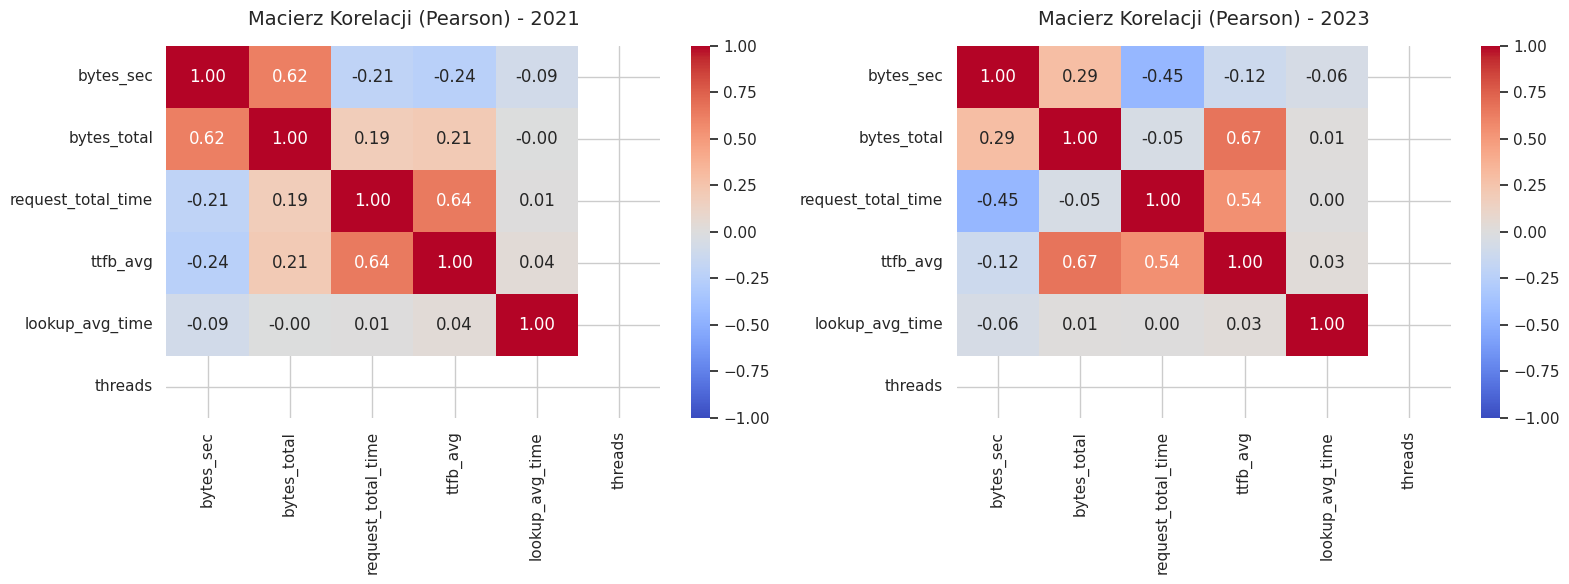

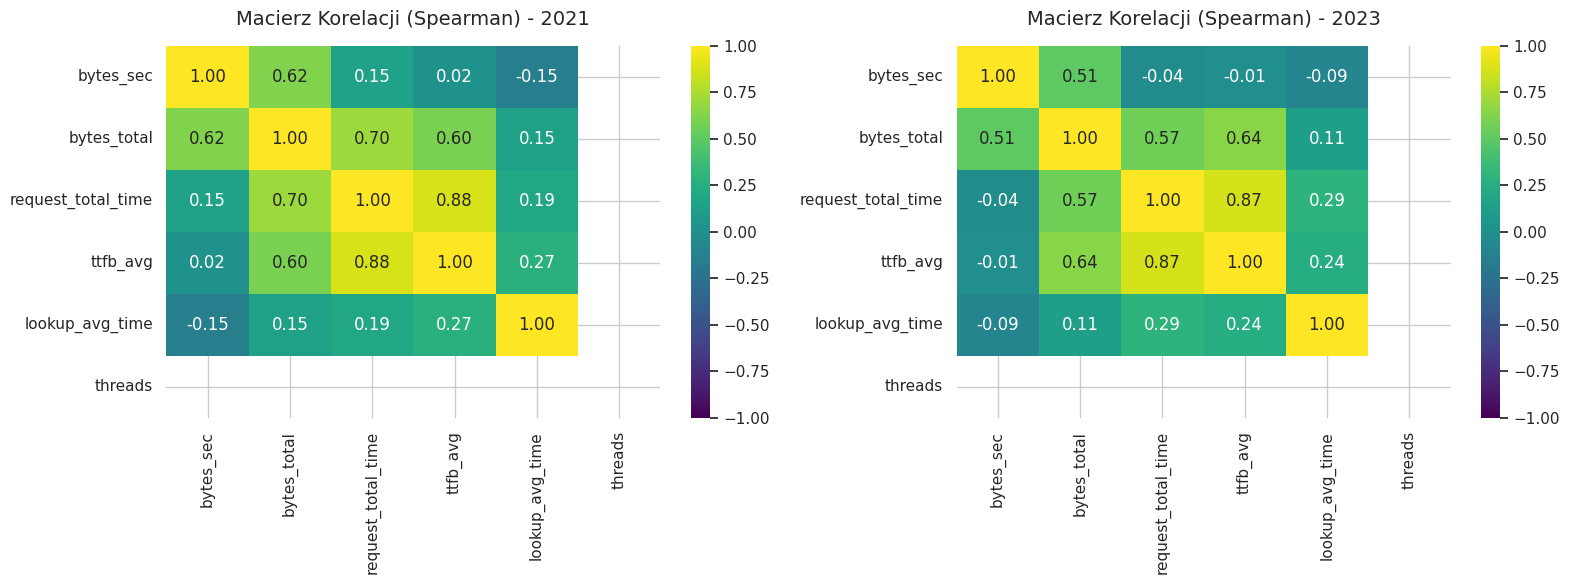

In [18]:
# Wybieramy numeryczne kolumny interesujące pod kątem oceny jakości połączenia sieciowego
corr_cols = [
    'bytes_sec',          # docelowa przepustowość (wydajność)
    'bytes_total',        # waga całkowita pobranych paczek
    'request_total_time', # sumaryczny czas żądania u ISP
    'ttfb_avg',           # średni czas oczekiwania do serwera brzegowego
    'lookup_avg_time',    # rozwiązywanie DNS
    'threads'             # liczba utworzonych równologłych wątków zapytania
]

# Obliczenie współczynników z próbki pomyślnych testów (successes == 1)
pearson_21 = valid_21[corr_cols].corr(method='pearson')
pearson_23 = valid_23[corr_cols].corr(method='pearson')

spearman_21 = valid_21[corr_cols].corr(method='spearman')
spearman_23 = valid_23[corr_cols].corr(method='spearman')

# WIZUALIZACJA - KORELACJA LINIOWA PEARSONA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_21, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Macierz Korelacji (Pearson) - 2021', fontsize=14, pad=15)

sns.heatmap(pearson_23, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Macierz Korelacji (Pearson) - 2023', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

# WIZUALIZACJA - KORELACJA MONOTONICZNA SPEARMANA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(spearman_21, annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Macierz Korelacji (Spearman) - 2021', fontsize=14, pad=15)

sns.heatmap(spearman_23, annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Macierz Korelacji (Spearman) - 2023', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

### 6. Modelowanie Predykcyjne (Klasyfikacja) na przekroju lat 2021-2023

W tej części dokumentu przeprowadzono eksperyment modelowania mający na celu odpowiedź na pytanie: **jak bardzo zmieniła się charakterystyka sieci i jej błędy między 2021 a 2023 rokiem?** W tym celu wytrenowano dwie osobne grupy modeli:
1. Wytrenowane na danych z **2021** roku.
2. Wytrenowane na danych z **2023** roku.

Każdy zestaw przetestowano krzyżowo na wstrzymanym zbiorze testowym z własnego roku, a następnie na danych z drugiego roku. Spadek metryki AUC (Area Under the ROC Curve) w testach krzyżowych sugeruje tzw. _Concept Drift_ (ewolucję danych pożądanych).

Zmienną docelową (Target) jest `successes` (0 - błąd, 1 - pomyślne). Cechy wejściowe `['bytes_total', 'threads', 'requests', 'connections', 'lookups', 'lookup_avg_time']` odrzucają prędkość transferu zapobiegając **wyciekowi danych** (Data Leakage). 
Wykorzystano modele: **Decision Tree**, **Random Forest** i **HistGradientBoostingClassifier**.

Dane 2021 -> Treningowe: 800000 próbek | Testowe: 200000 próbek
Dane 2023 -> Treningowe: 800000 próbek | Testowe: 200000 próbek

>>> TRENOWANIE ZESTAWU 2021 <<<

--- Model: Decision Tree | Trenowano: 2021 | Testowano: 2021 ---
ROC AUC: 0.9876
Raport Klasyfikacji (Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     22929
           1       0.99      0.98      0.99    177071

    accuracy                           0.98    200000
   macro avg       0.93      0.96      0.94    200000
weighted avg       0.98      0.98      0.98    200000

--------------------------------------------------
--- Model: Decision Tree | Trenowano: 2021 | Testowano: 2023 ---
ROC AUC: 0.9995
Raport Klasyfikacji (Recall, F1-Score):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     75290
           1       1.00      1.00      1.00    124710

    accuracy                           1.00    200000


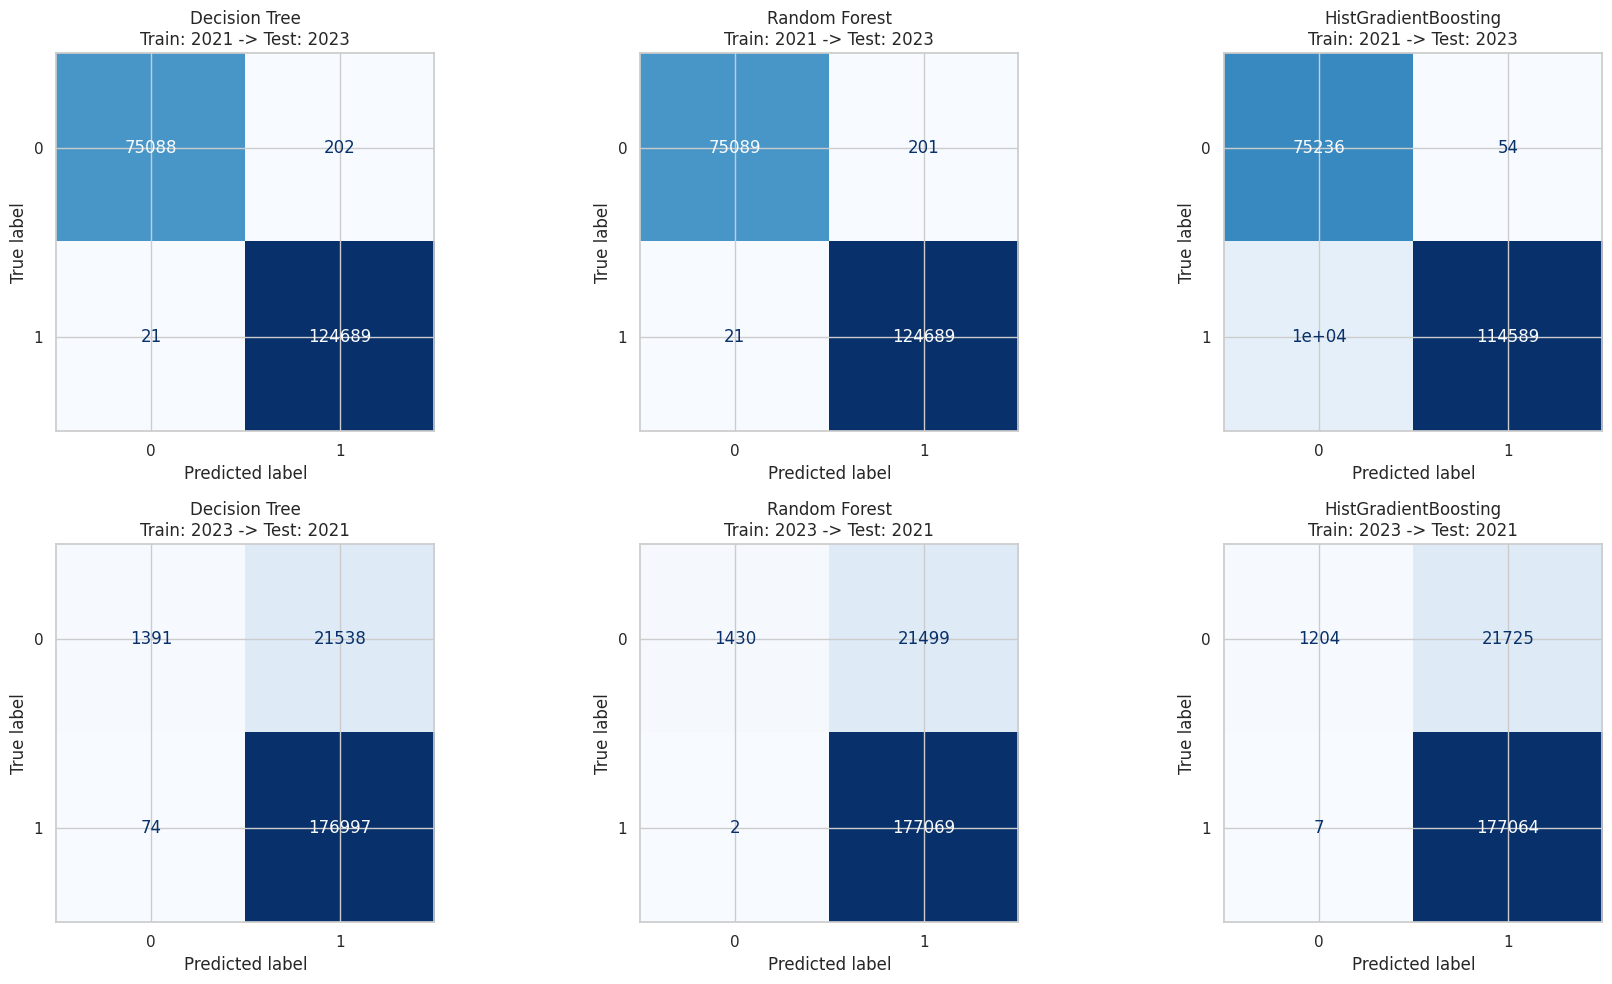

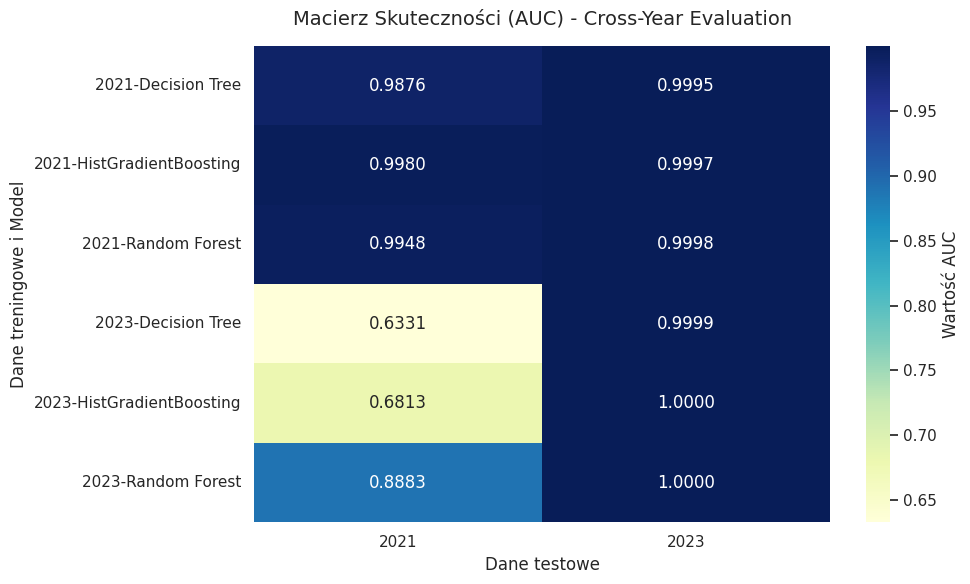

Test Year                            2021      2023
Train Year Model                                   
2021       Decision Tree         0.987555  0.999502
           HistGradientBoosting  0.998025  0.999736
           Random Forest         0.994762  0.999786
2023       Decision Tree         0.633128  0.999930
           HistGradientBoosting  0.681299  0.999962
           Random Forest         0.888332  0.999989

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay

# 1. Definiowanie zmiennych oraz zmiennej Celu
features = ['bytes_total', 'threads', 'requests', 'connections', 'lookups', 'lookup_avg_time']
target = 'successes'

# 2. Czyszczenie i przygotowanie podzbiorów (2021 oraz 2023)
df_21_clean = df_2021[features + [target]].dropna()
df_23_clean = df_2023[features + [target]].dropna()

X_21, y_21 = df_21_clean[features], df_21_clean[target]
X_23, y_23 = df_23_clean[features], df_23_clean[target]

# 3. Podział zbiorów na treningowy i testowy z zachowaniem proporcji
X_train_21, X_test_21, y_train_21, y_test_21 = train_test_split(X_21, y_21, test_size=0.2, random_state=42, stratify=y_21)
X_train_23, X_test_23, y_train_23, y_test_23 = train_test_split(X_23, y_23, test_size=0.2, random_state=42, stratify=y_23)

print("="*60)
print(f"Dane 2021 -> Treningowe: {len(X_train_21)} próbek | Testowe: {len(X_test_21)} próbek")
print(f"Dane 2023 -> Treningowe: {len(X_train_23)} próbek | Testowe: {len(X_test_23)} próbek")
print("="*60 + "\n")

def create_models():
    return {
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
        "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=50, random_state=42)
    }

models_trained_on_21 = create_models()
models_trained_on_23 = create_models()

# Wizualizacja macierzy pomyłek dla weryfikacji CROSS-YEAR (najciekawszy przypadek: trenowane na jednym, testowane na drugim)
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(18, 10))

results_summary = []

def evaluate_and_report(model, model_name, X_test, y_test, train_year, test_year, ax=None):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    results_summary.append({'Train Year': train_year, 'Test Year': test_year, 'Model': model_name, 'AUC': auc})
    
    print(f"--- Model: {model_name} | Trenowano: {train_year} | Testowano: {test_year} ---")
    print(f"ROC AUC: {auc:.4f}")
    print("Raport Klasyfikacji (Recall, F1-Score):")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-" * 50)
    
    if ax is not None:
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'{model_name}\nTrain: {train_year} -> Test: {test_year}')

# 4. Trening 2021
print(">>> TRENOWANIE ZESTAWU 2021 <<<\n")
for i, (name, model) in enumerate(models_trained_on_21.items()):
    model.fit(X_train_21, y_train_21)
    # Test w obrębie 2021
    evaluate_and_report(model, name, X_test_21, y_test_21, '2021', '2021')
    # Test krzyżowy na 2023 (oraz rysowanie na górnym rzędzie wykresów)
    evaluate_and_report(model, name, X_test_23, y_test_23, '2021', '2023', ax=axes_cm[0, i])
print("\n")

# 5. Trening 2023
print(">>> TRENOWANIE ZESTAWU 2023 <<<\n")
for i, (name, model) in enumerate(models_trained_on_23.items()):
    model.fit(X_train_23, y_train_23)
    # Test w obrębie 2023
    evaluate_and_report(model, name, X_test_23, y_test_23, '2023', '2023')
    # Test krzyżowy na 2021 (oraz rysowanie na dolnym rzędzie wykresów)
    evaluate_and_report(model, name, X_test_21, y_test_21, '2023', '2021', ax=axes_cm[1, i])
print("\n")

plt.tight_layout()
plt.show()

# 6. Podsumowanie krzyżowe (Concept Drift) na Wykresie Głównego AUC
df_results = pd.DataFrame(results_summary)

# Tworzymy czytelniejszy kafelkowy wykres typu Heatmap dla porównania zmian wskaźnika AUC
plt.figure(figsize=(10, 6))
auc_pivot = df_results.pivot_table(index=['Train Year', 'Model'], columns='Test Year', values='AUC')

sns.heatmap(auc_pivot, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Wartość AUC'})
plt.title("Macierz Skuteczności (AUC) - Cross-Year Evaluation", fontsize=14, pad=15)
plt.ylabel("Dane treningowe i Model", fontsize=12)
plt.xlabel("Dane testowe", fontsize=12)
plt.tight_layout()
plt.show()

display(auc_pivot)